# Track ETA Model — Insights Dashboard

Interactive exploration of the LightGBM delay-factor model.
Run all cells (`Cell ▸ Run All`) after each retrain to review:

| Section | What you learn |
|---------|----------------|
| **Training History** | Metric trends across runs |
| **Feature Importance** | Which inputs drive predictions |
| **SHAP Explainability** | *Why* the model makes each prediction |
| **Prediction Distribution** | Overall model behaviour shape |
| **Error Analysis** | Where the model struggles |

In [73]:
"""Cell 1 — Setup: imports, paths, load model & data."""

from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve project root from this notebook's location.
# Works whether launched from TrackBackend/ or app/ml/.
import os as _os
_NB_DIR = Path(
    _os.environ.get(
        'NOTEBOOK_ROOT',
        Path('__file__').resolve().parent
        if '__file__' in dir()
        else Path.cwd(),
    )
)
_ROOT = _NB_DIR
# Walk up until we find the app/ package.
for _ in range(5):
    if (_ROOT / 'app').is_dir():
        break
    _ROOT = _ROOT.parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

# --- project imports ---
from app.ml.delay_model import (
    FEATURE_NAMES,
    MODEL_PATH,
    SEASON_ENCODING,
)
from app.ml import data_loaders

import joblib

# Optional: SHAP (gracefully degrade if not installed).
try:
    import shap
    _HAS_SHAP = True
    print(f'SHAP {shap.__version__} \u2713')
except ImportError:
    _HAS_SHAP = False
    print('\u26a0 SHAP not installed \u2014 run: pip install shap')

# Plot style.
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

# Paths.
_DATA_DIR = _ROOT / 'app' / 'data'
_RUNS_LOG = _DATA_DIR / 'training_runs.jsonl'

print(f'Model path : {MODEL_PATH}')
print(f'Runs log   : {_RUNS_LOG}')
print(f'Features   : {len(FEATURE_NAMES)}')

SHAP 0.51.0 ✓
Model path : /Users/jeffreyfernandez/code/Track/TrackBackend/app/data/delay_model.pkl
Runs log   : /Users/jeffreyfernandez/code/Track/TrackBackend/app/data/training_runs.jsonl
Features   : 14


In [74]:
"""Cell 2 — Load the trained model."""

model = joblib.load(MODEL_PATH)
print(f'Model type       : {type(model).__name__}')
print(f'Trees            : {model.n_estimators}')
print(f'Features trained : {model.n_features_in_}')
print(f'Model file size  : {MODEL_PATH.stat().st_size / 1024:.0f} KB')

Model type       : LGBMRegressor
Trees            : 212
Features trained : 14
Model file size  : 1476 KB


---
## 1 Training Run History

Each `python -m app.ml.train_model` invocation appends a JSONL record.
Track R², MAE, accuracy, and model size over time.

In [75]:
"""Cell 3 — Parse training run log and plot metrics."""

if _RUNS_LOG.exists():
    runs = [
        json.loads(line)
        for line in _RUNS_LOG.read_text().splitlines()
        if line.strip()
    ]
    df_runs = pd.DataFrame(runs)
    df_runs['timestamp'] = pd.to_datetime(df_runs['timestamp'])
    df_runs = df_runs.sort_values('timestamp').reset_index(drop=True)
    df_runs['run'] = range(1, len(df_runs) + 1)

    print(f'{len(df_runs)} training run(s) logged.')
    display(df_runs[[
        'run', 'timestamp', 'holdout_mae', 'holdout_r2',
        'eta_accuracy', 'n_estimators', 'total_samples',
        'model_size_kb',
    ]])

    if len(df_runs) >= 2:
        fig, axes = plt.subplots(2, 2, figsize=(12, 7))
        for ax, col, label, colour in zip(
            axes.flat,
            ['holdout_mae', 'holdout_r2',
             'eta_accuracy', 'model_size_kb'],
            ['Holdout MAE', 'Holdout R2',
             'ETA Accuracy', 'Model Size (KB)'],
            ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6'],
        ):
            ax.plot(
                df_runs['run'], df_runs[col],
                'o-', color=colour, linewidth=2,
            )
            ax.set_xlabel('Run')
            ax.set_ylabel(label)
            ax.set_title(label, fontsize=11, fontweight='bold')
        fig.suptitle(
            'Training Run History',
            fontsize=14, fontweight='bold',
        )
        fig.tight_layout()
        plt.show()
    else:
        print('(Need 2+ runs to plot trends.)')
else:
    print('No training_runs.jsonl found.')
    df_runs = pd.DataFrame()

1 training run(s) logged.


,run,timestamp,holdout_mae,holdout_r2,eta_accuracy,n_estimators,total_samples,model_size_kb
0,1,2026-04-01 23:59:06.399492+00:00,0.13064,0.71632,0.9525,212,3873270,1476.0


(Need 2+ runs to plot trends.)


---
## 2 Feature Importance (Gain)

LightGBM's split-gain importance: how much each feature
reduces the loss across all trees.

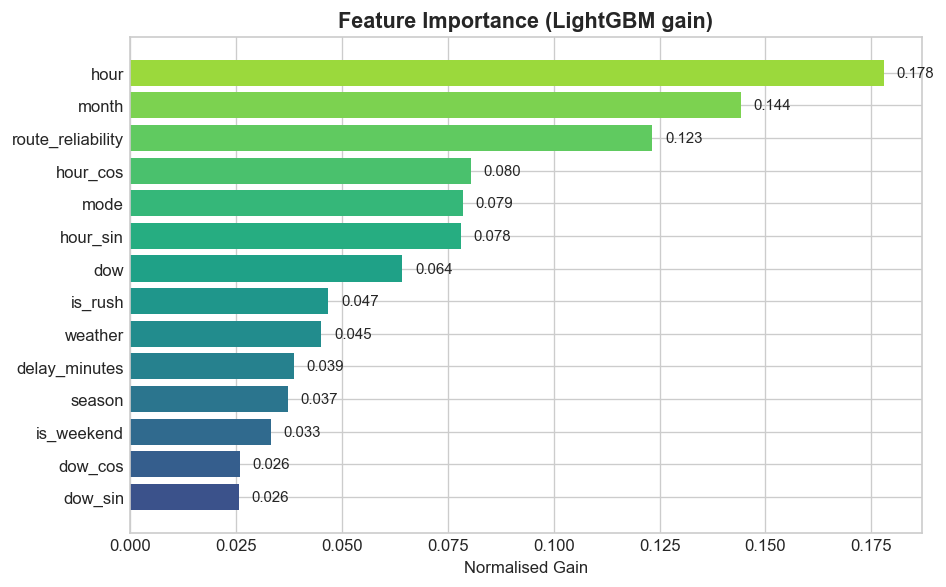

In [76]:
"""Cell 4 — Feature importance bar chart."""

n_model_feats = model.n_features_in_
names = FEATURE_NAMES[:n_model_feats]
importances = model.feature_importances_

# Normalise to sum = 1.
importances = importances / importances.sum()

df_imp = pd.DataFrame(
    {'feature': names, 'importance': importances},
)
df_imp = df_imp.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colours = plt.cm.viridis(
    np.linspace(0.25, 0.85, len(df_imp)),
)
ax.barh(df_imp['feature'], df_imp['importance'], color=colours)
ax.set_xlabel('Normalised Gain')
ax.set_title(
    'Feature Importance (LightGBM gain)',
    fontsize=13, fontweight='bold',
)
for i, v in enumerate(df_imp['importance']):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)
fig.tight_layout()
plt.show()

---
## 3 Load Holdout Data

Rebuild the same train/test split so we can compute SHAP values
and error analyses on the *held-out* set the model has never seen.

In [77]:
"""Cell 5 — Rebuild dataset and holdout split."""

import sqlite3
from app.ml.train_model import (
    _build_route_table,
    generate_bootstrap_samples,
)
from sklearn.model_selection import train_test_split

_DB = _ROOT / 'app' / 'data' / 'transit_schedule.db'

print(f'GTFS DB: {_DB}  (exists={_DB.exists()})')

conn = sqlite3.connect(str(_DB))
route_table = _build_route_table(conn)
conn.close()

# Bootstrap synthetic data.
X_boot, y_boot, w_boot = generate_bootstrap_samples(route_table)

# MTA open data.
X_mta, y_mta, w_mta = data_loaders.load_mta_open_data()

# Combine.
X_all = np.array(X_boot + X_mta, dtype=np.float32)
y_all = np.array(y_boot + y_mta, dtype=np.float32)
w_all = np.array(w_boot + w_mta, dtype=np.float32)

# Truncate to model's feature count (backward compat).
X_all = X_all[:, :n_model_feats]

# Same 85/15 split and seed as train_model.py.
X_train, X_test, y_train, y_test, w_train, w_test = (
    train_test_split(
        X_all, y_all, w_all,
        test_size=0.15, random_state=42,
    )
)

df_test = pd.DataFrame(X_test, columns=names)
df_test['y_true'] = y_test
df_test['y_pred'] = model.predict(df_test[names])
df_test['abs_error'] = np.abs(
    df_test['y_true'] - df_test['y_pred'],
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Holdout MAE : {df_test["abs_error"].mean():.5f}')

GTFS DB: /Users/jeffreyfernandez/code/Track/TrackBackend/app/data/transit_schedule.db  (exists=True)
  Reading routes and trips from GTFS DB ...
  Built route table: 421 routes
  Generating bootstrap training samples ...
  Generated 621,936 bootstrap samples
  OTP reliability built for 28 subway lines
  Subway customer journey: 165,840 samples
  LIRR OTP: 94,076 samples
  Metro-North OTP: 25,550 samples
  Bus customer journey: 1,935,120 samples
  Bus wait assessment: 9,750 samples
  Subway delay incidents: 795 samples
  Subway trains delayed: 2,158 samples
  Bus service delivered: 5,895 samples
  Bus segment speeds: 1,000,000 samples
  MTA service alerts: 12,150 samples

  MTA open data total: 3,251,334 samples across all datasets
Train: 3,292,279  |  Test: 580,991
Holdout MAE : 0.12237


---
## 4 SHAP Explainability

SHAP (SHapley Additive exPlanations) decomposes each prediction
into per-feature contributions. This tells you *why* the model
predicts a higher or lower delay factor for a given context.

> Computed on a 10K stratified sample of the holdout set for speed.

SHAP computed on 10,000 holdout samples.


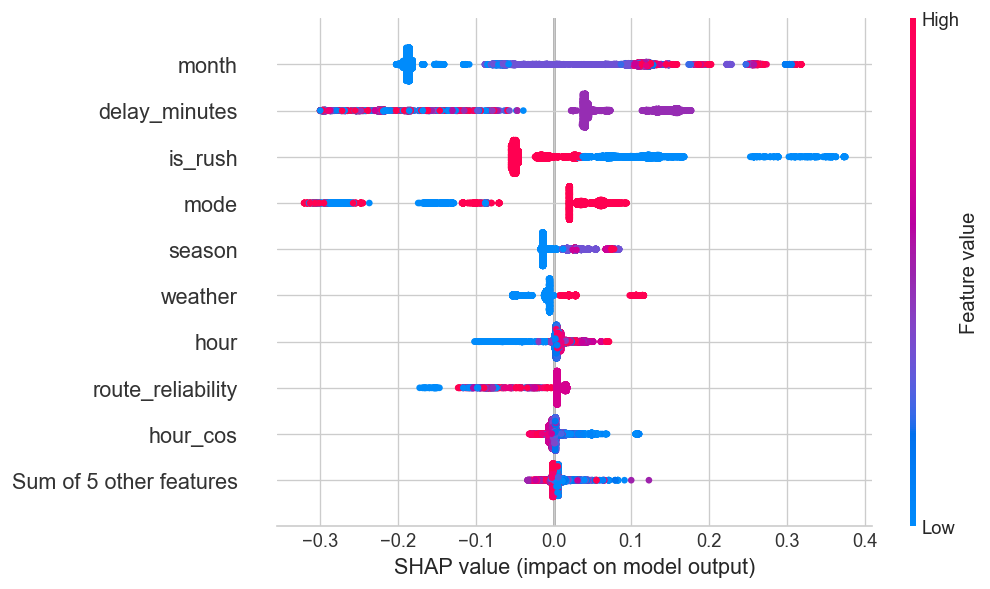

In [78]:
"""Cell 6 — SHAP beeswarm (summary) plot."""

_SHAP_N = min(10_000, len(X_test))

if _HAS_SHAP:
    rng = np.random.default_rng(42)
    idx_sample = rng.choice(
        len(X_test), size=_SHAP_N, replace=False,
    )
    X_shap = pd.DataFrame(
        X_test[idx_sample], columns=names,
    )

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_shap)

    print(f'SHAP computed on {_SHAP_N:,} holdout samples.')
    shap.plots.beeswarm(shap_values, show=True)
else:
    print('Skipped \u2014 install shap to enable.')

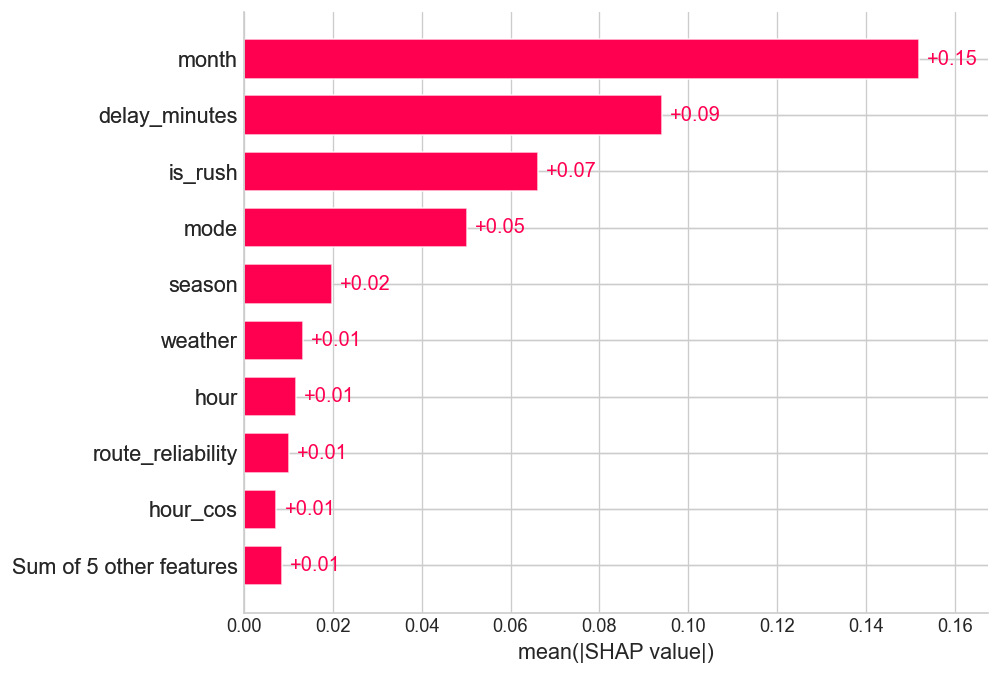

In [79]:
"""Cell 7 — SHAP bar plot (global feature importance)."""

if _HAS_SHAP:
    shap.plots.bar(shap_values, show=True)
else:
    print('Skipped \u2014 install shap to enable.')

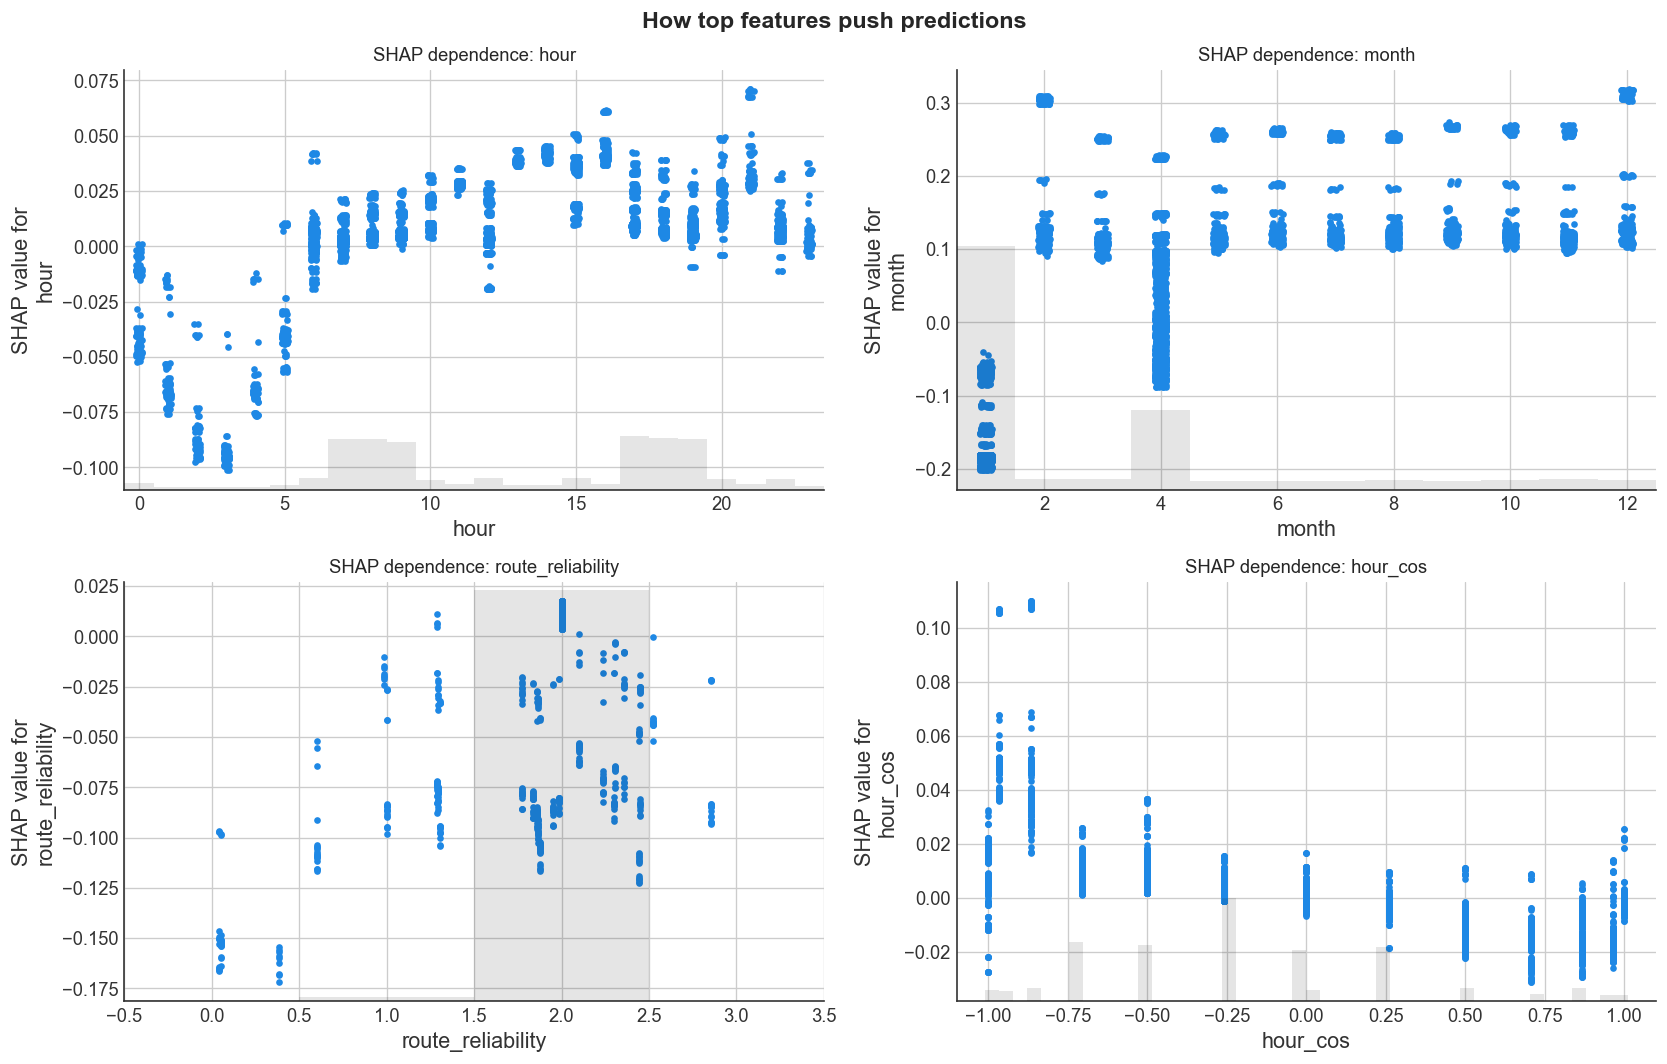

In [80]:
"""Cell 8 — SHAP dependence plots for the top 4 features."""

if _HAS_SHAP:
    top4 = (
        df_imp.sort_values('importance', ascending=False)
        .head(4)['feature'].tolist()
    )
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for ax, feat in zip(axes.flat, top4):
        shap.plots.scatter(
            shap_values[:, feat], ax=ax, show=False,
        )
        ax.set_title(f'SHAP dependence: {feat}', fontsize=11)
    fig.suptitle(
        'How top features push predictions',
        fontsize=14, fontweight='bold',
    )
    fig.tight_layout()
    plt.show()
else:
    print('Skipped \u2014 install shap to enable.')

---
## 5 Prediction Distribution

What does the model's output *look like*?
The delay factor should cluster around 1.0 (on time) with a
right tail toward 1.3–1.5 (chronically late).

In [ ]:
"""Cell 9 — Predicted vs actual distribution."""

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of predicted vs actual.
axes[0].hist(
    df_test['y_true'], bins=60,
    alpha=0.5, label='Actual', color='#3498db',
)
axes[0].hist(
    df_test['y_pred'], bins=60,
    alpha=0.5, label='Predicted', color='#e74c3c',
)
axes[0].set_xlabel('Delay Factor')
axes[0].set_ylabel('Count')
axes[0].set_title(
    'Predicted vs Actual Distribution', fontweight='bold',
)
axes[0].legend()

# Scatter: actual vs predicted.
sample_n = min(20_000, len(df_test))
sample = df_test.sample(n=sample_n, random_state=0)
axes[1].scatter(
    sample['y_true'], sample['y_pred'],
    alpha=0.08, s=4, color='#2c3e50',
)
lo = df_test['y_true'].min()
hi = df_test['y_true'].max()
axes[1].plot(
    [lo, hi], [lo, hi], 'r--',
    linewidth=1.5, label='Perfect',
)
axes[1].set_xlabel('Actual Delay Factor')
axes[1].set_ylabel('Predicted Delay Factor')
axes[1].set_title(
    'Actual vs Predicted (holdout)', fontweight='bold',
)
axes[1].legend()

fig.tight_layout()
plt.show()

print(
    f'Predictions: '
    f'mean={df_test["y_pred"].mean():.4f}, '
    f'std={df_test["y_pred"].std():.4f}, '
    f'min={df_test["y_pred"].min():.4f}, '
    f'max={df_test["y_pred"].max():.4f}',
)

---
## 6 Error Analysis

Where does the model struggle? Break down MAE by:
- Hour of day (rush vs off-peak)
- Transit mode (subway vs bus vs rail)
- Route reliability tier

In [ ]:
"""Cell 10 — MAE by hour of day."""

df_test['hour_int'] = df_test['hour'].astype(int)
hourly = (
    df_test.groupby('hour_int')['abs_error']
    .agg(['mean', 'count'])
    .reset_index()
)
hourly.columns = ['hour', 'mae', 'n']

fig, ax1 = plt.subplots(figsize=(11, 5))
colour_bar = '#3498db'
colour_line = '#e74c3c'

ax1.bar(
    hourly['hour'], hourly['n'],
    color=colour_bar, alpha=0.35, label='Sample count',
)
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Sample Count', color=colour_bar)
ax1.tick_params(axis='y', labelcolor=colour_bar)

ax2 = ax1.twinx()
ax2.plot(
    hourly['hour'], hourly['mae'],
    'o-', color=colour_line, linewidth=2, label='MAE',
)
ax2.set_ylabel('MAE', color=colour_line)
ax2.tick_params(axis='y', labelcolor=colour_line)

# Highlight rush hours.
for rng_pair in [(7, 9), (17, 19)]:
    ax1.axvspan(
        rng_pair[0] - 0.5, rng_pair[1] + 0.5,
        alpha=0.08, color='orange',
        label='Rush' if rng_pair[0] == 7 else '',
    )

ax1.set_title(
    'MAE by Hour of Day',
    fontsize=13, fontweight='bold',
)
ax1.set_xticks(range(24))
fig.legend(
    loc='upper right', bbox_to_anchor=(0.95, 0.95),
)
fig.tight_layout()
plt.show()

In [ ]:
"""Cell 11 — MAE by transit mode."""

# mode: 0=subway, 1=bus, 2=commuter rail
_MODE_LABELS = {
    0: 'Subway', 1: 'Bus', 2: 'Commuter Rail',
}
df_test['mode_label'] = (
    df_test['mode'].map(_MODE_LABELS).fillna('Unknown')
)
mode_stats = (
    df_test.groupby('mode_label')
    .agg(
        mae=('abs_error', 'mean'),
        n=('abs_error', 'count'),
        mean_pred=('y_pred', 'mean'),
    )
    .sort_values('mae', ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(
    mode_stats.index, mode_stats['mae'],
    color=['#e74c3c', '#f39c12', '#2ecc71'],
)
for bar, n in zip(bars, mode_stats['n']):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'n={n:,}', va='center', fontsize=9,
    )
ax.set_xlabel('Mean Absolute Error')
ax.set_title(
    'MAE by Transit Mode',
    fontsize=13, fontweight='bold',
)
fig.tight_layout()
plt.show()

display(mode_stats)

In [ ]:
"""Cell 12 — MAE by route reliability tier."""

df_test['reliability_tier'] = (
    df_test['route_reliability'].round().astype(int)
)
tier_stats = (
    df_test.groupby('reliability_tier')
    .agg(
        mae=('abs_error', 'mean'),
        n=('abs_error', 'count'),
        mean_factor=('y_pred', 'mean'),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
colours = plt.cm.RdYlGn_r(
    np.linspace(0.15, 0.85, len(tier_stats)),
)
ax.bar(
    tier_stats['reliability_tier'],
    tier_stats['mae'],
    color=colours, edgecolor='white',
)
for _, row in tier_stats.iterrows():
    ax.text(
        row['reliability_tier'],
        row['mae'] + 0.002,
        f'n={int(row["n"]):,}',
        ha='center', fontsize=9,
    )
ax.set_xlabel(
    'Route Reliability Tier  (0 = best, 4 = worst)',
)
ax.set_ylabel('MAE')
ax.set_title(
    'MAE by Route Reliability',
    fontsize=13, fontweight='bold',
)
ax.set_xticks(tier_stats['reliability_tier'])
fig.tight_layout()
plt.show()

display(tier_stats)

---
## 7 Residual Analysis

Check for systematic bias: does the model over-predict
or under-predict in certain conditions?

In [ ]:
"""Cell 13 — Residual plots."""

df_test['residual'] = df_test['y_pred'] - df_test['y_true']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Residual histogram.
axes[0].hist(
    df_test['residual'], bins=80,
    color='#8e44ad', alpha=0.7,
)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Residual (pred minus actual)')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual Distribution', fontweight='bold')

# 2. Residual vs predicted.
sample2 = df_test.sample(
    n=min(15_000, len(df_test)), random_state=1,
)
axes[1].scatter(
    sample2['y_pred'], sample2['residual'],
    alpha=0.08, s=3, c='#2c3e50',
)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted', fontweight='bold')

# 3. Mean residual by hour (bias check).
hourly_bias = df_test.groupby('hour_int')['residual'].mean()
axes[2].bar(
    hourly_bias.index, hourly_bias.values,
    color=[
        '#e74c3c' if v > 0 else '#2ecc71'
        for v in hourly_bias.values
    ],
)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Mean Residual')
axes[2].set_title('Mean Bias by Hour', fontweight='bold')
axes[2].set_xticks(range(24))

fig.suptitle(
    'Residual Analysis',
    fontsize=14, fontweight='bold', y=1.02,
)
fig.tight_layout()
plt.show()

print(
    f'Overall bias (mean residual): '
    f'{df_test["residual"].mean():.5f}',
)
print(f'Residual std: {df_test["residual"].std():.5f}')

---
## 8 Model Health Summary

One-glance table of the model's vital signs.

In [ ]:
"""Cell 14 — Health summary card."""

from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(df_test['y_true'], df_test['y_pred'])
r2 = r2_score(df_test['y_true'], df_test['y_pred'])

latest_run = (
    df_runs.iloc[-1] if not df_runs.empty else {}
)
eta_acc = latest_run.get('eta_accuracy', 'N/A')
if isinstance(eta_acc, float):
    eta_acc = f'{eta_acc:.1%}'

summary = {
    'Holdout MAE': f'{mae:.5f}',
    'Holdout R2': f'{r2:.5f}',
    'ETA Accuracy (benchmark)': eta_acc,
    'Trees / Features': (
        f'{model.n_estimators} / {model.n_features_in_}'
    ),
    'Training Samples': f'{len(X_train) + len(X_test):,}',
    'Model File Size': (
        f'{MODEL_PATH.stat().st_size / 1024:.0f} KB'
    ),
    'Mean Bias': f'{df_test["residual"].mean():.5f}',
    'Training Runs Logged': str(len(df_runs)),
}

print('\n' + '=' * 44)
print('  MODEL HEALTH SUMMARY')
print('=' * 44)
for k, v in summary.items():
    print(f'  {k:<28s} {v}')
print('=' * 44)

---

### Quick actions

```bash
# Retrain the model
python -m app.ml.train_model

# Retrain with Optuna tuning (takes ~4 min)
python -m app.ml.train_model --tune

# Regenerate the static dashboard PNG
python -m app.ml.visualize -o ml_dashboard.png

# Then re-run this notebook for updated insights!
```